### 🎯 [미션] 주석이 달린 줄의 None 또는 _______ 부분을 채워 코드를 완성하세요.

각 셀을 순서대로 실행(Shift + Enter)해야 합니다.

---

#### 1️⃣  필요한 라이브러리 설치 및 불러오기

In [1]:
# YOLO 라이브러리 설치 (최초 1회만 실행)
!pip install ultralytics

- YOLO 모델을 사용하기 위해서는 `ultralytics` 라이브러리의 핵심 모듈을 불러와야 합니다.

In [66]:
# 🎯 [미션] ultralytics 라이브러리에서 YOLO 모듈을 불러오세요.
from ultralytics import YOLO
from ultralytics import settings
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

---
#### 2️⃣ 경로 설정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
cd "/content/drive/MyDrive/2026_AI_Advanced_Study-main/4차시/01_AR/code"

In [67]:
# 현재 작업 디렉토리 확인
current_dir = os.getcwd()
new_runs_dir = os.path.abspath(os.path.join(current_dir, '../runs'))
new_data_dir = os.path.abspath(os.path.join(current_dir, '../data'))
# YOLO 설정 업데이트
settings.update({"runs_dir": new_runs_dir})
settings.update({"datasets_dir": new_data_dir})
settings.update({"wandb": False})  # wandb 로깅 비활성화

print(f"✅ 작업 디렉토리: {current_dir}")

print("\n✅ 경로 설정 완료!")

✅ 작업 디렉토리: /home/nute11a/workspace/2026_AI_Advanced_Study/4차시/01_AR/code_GT

✅ 경로 설정 완료!


---
### 3️⃣ 학습된 모델 불러오기 🔍
train.ipynb에서 학습한 모델의 경로를 찾아서 아래 MODEL_PATH 변수에 입력해주세요.

In [68]:
# 🎯 [미션] (01_train.ipynb에서 학습 후 생성된 weights/best.pt 파일 경로를 지정하세요)
model_path = '../runs/pose/train6/weights/best.pt'#'../runs/pose/train6/weights/best.pt' 
model = YOLO(model_path)

---

### 4️⃣ 얼굴 랜드마크 68개 점 확인하기 🙂

우리 모델이 얼굴에서 찾아낸 68개의 점을 시각화해봅시다.

각 점의 번호를 확인하면서, 어느 점이 **코**, **눈**, **입**에 해당하는지 파악해보세요!

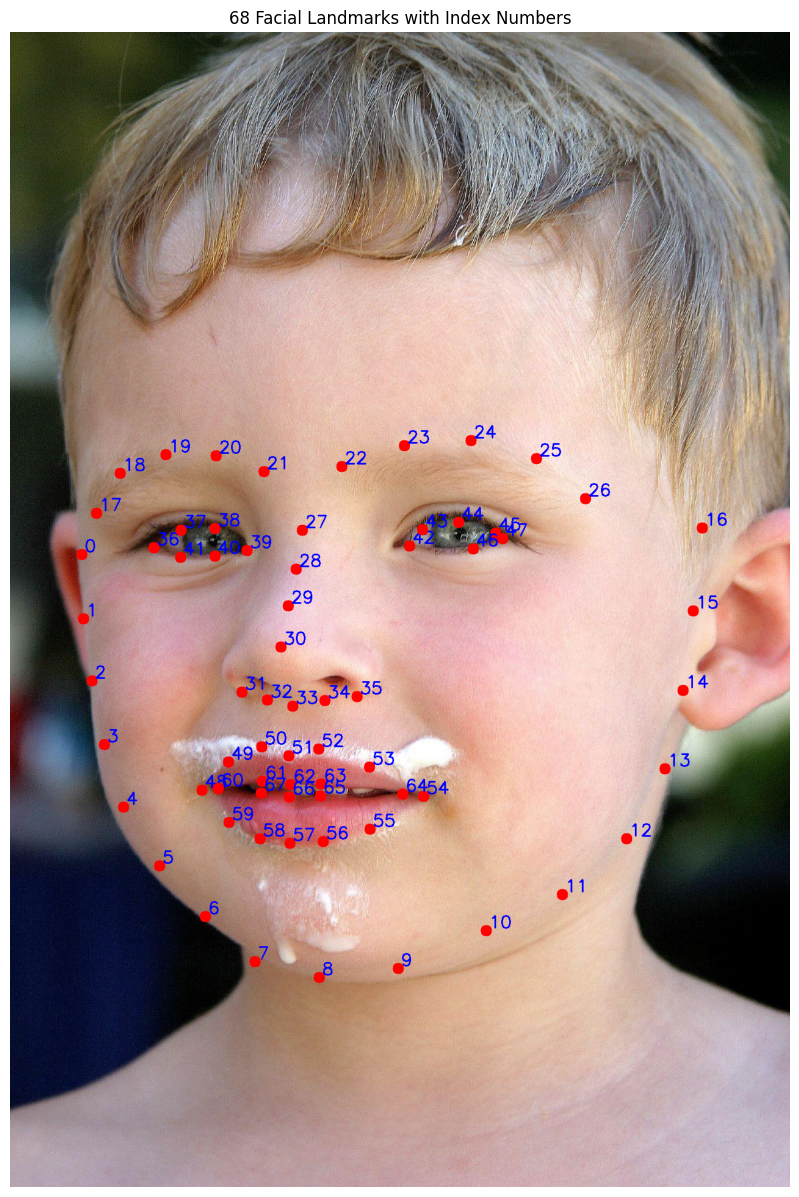


💡 위 이미지를 확대해서 각 점의 번호를 확인하세요!
코 끝은 몇 번일까요? 눈은요? 입은요?


In [23]:
# 테스트 이미지 경로 (여러분의 이미지로 변경 가능)
test_image_path = '../data/test/images/26638112_1.jpg'

# 모델 예측
results = model(test_image_path, verbose=False)

# 이미지와 키포인트 가져오기
img = results[0].orig_img.copy()
keypoints = results[0].keypoints.xy[0].cpu().numpy()

# 68개 점에 번호 표시
for i, (x, y) in enumerate(keypoints):
    cv2.circle(img, (int(x), int(y)), 10, (0, 0, 255), -1)
    cv2.putText(img, str(i), (int(x)+5, int(y)-5), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

# 결과 시각화
plt.figure(figsize=(15, 15))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('68 Facial Landmarks with Index Numbers')
plt.axis('off')
plt.show()

print("\n💡 위 이미지를 확대해서 각 점의 번호를 확인하세요!")
print("코 끝은 몇 번일까요? 눈은요? 입은요?")

---

### 🎨 AR 필터 만들기 시작!

이제부터 위에서 찾은 68개 점을 활용해서 **나만의 AR 필터**를 만들어봅시다!

**3단계 미션:**
- 🔴 **Level 1**: 루돌프 빨간 코 만들기
- 🕶️ **Level 2**: 힙한 선글라스 필터 만들기


In [62]:
def overlay_transparent(background, overlay, x, y):
    h, w = overlay.shape[:2]
    bg_h, bg_w = background.shape[:2]
    
    # 합성 가능한 영역 계산
    src_x_start = max(0, -x)
    src_y_start = max(0, -y)
    dst_x_start = max(0, x)
    dst_y_start = max(0, y)
    
    src_x_end = min(w, bg_w - x)
    src_y_end = min(h, bg_h - y)
    dst_x_end = min(bg_w, x + w)
    dst_y_end = min(bg_h, y + h)
    
    # 합성 불가능하면 리턴
    if (src_x_end <= src_x_start or src_y_end <= src_y_start or
        dst_x_end <= dst_x_start or dst_y_end <= dst_y_start):
        return background
    
    # 영역 추출
    overlay_region = overlay[src_y_start:src_y_end, src_x_start:src_x_end]
    overlay_bgr = overlay_region[:, :, :3]
    overlay_alpha = overlay_region[:, :, 3:] / 255.0
    background_region = background[dst_y_start:dst_y_end, dst_x_start:dst_x_end]
    
    # Alpha blending
    blended = (overlay_bgr * overlay_alpha + 
               background_region * (1 - overlay_alpha)).astype('uint8')
    
    background[dst_y_start:dst_y_end, dst_x_start:dst_x_end] = blended
    
    return background

---
### 5️⃣ Level 1: 루돌프 빨간 코 만들기 🔴 

##### 목표
- 코 끝 랜드마크에 빨간 원 그리기
- 얼굴 크기에 비례해서 코 크기 자동 조절

##### 핵심
1. **기준점 설정**: 코 끝 좌표
2. **크기 조절**: 두 눈 사이 거리로 얼굴 크기 파악
3. **비율 계산**: `코 반지름 = 눈 간격 × 0.15`

In [72]:
def draw_rudolf_nose(frame, model, rudolf_nose_img):

    # 🎯 [미션 1] AI 모델로 얼굴 랜드마크 찾기
    results = model(frame, verbose=False)
    
    # 예외 처리: 얼굴이 감지되지 않았으면 바로 종료
    if results[0].keypoints is None or len(results[0].keypoints.xy) == 0:
        return frame
    
    # 결과에서 좌표 정보만 꺼내기
    keypoints = results[0].keypoints.xy[0].cpu().numpy()
    
    # 🎯 [미션 2] 코 끝(30번 인덱스) 좌표 가져오기
    nose_tip = keypoints[30]
    
    # 양쪽 눈의 중심점 구하기 (36~41: 왼쪽 눈, 42~47: 오른쪽 눈)
    left_eye = keypoints[36:42].mean(axis=0)
    right_eye = keypoints[42:47].mean(axis=0)
    
    # 🎯 [미션 3] 두 눈 사이의 거리(Distance) 계산
    # 힌트: np.linalg.norm 함수는 두 점 사이의 거리를 구하기 
    # 힌트: ||왼쪽 눈 중심 - 오른쪽 눈 중심||2
    eye_distance = np.linalg.norm(left_eye - right_eye)
    
    # 스티커 크기 설정 (눈 사이 거리의 30% 크기)
    nose_width = int(eye_distance * 0.3)
    
    # 원본 비율을 유지하며 높이 계산 및 리사이즈
    aspect_ratio = rudolf_nose_img.shape[0] / rudolf_nose_img.shape[1]
    nose_height = int(nose_width * aspect_ratio)
    nose_resized = cv2.resize(rudolf_nose_img, (nose_width, nose_height))
    
    # 🎯 [미션 4] 스티커를 붙일 시작점(좌상단) 계산
    # 힌트: 중심점(코 끝)에서 너비와 높이의 절반만큼 빼주면 시작점이 됨
    x_start = int(nose_tip[0] - nose_width // 2)
    y_start = int(nose_tip[1] - nose_height // 2)
    
    # 이미지 합성 (투명 배경 처리 포함)
    frame = overlay_transparent(frame, nose_resized, x_start, y_start)
    
    return frame

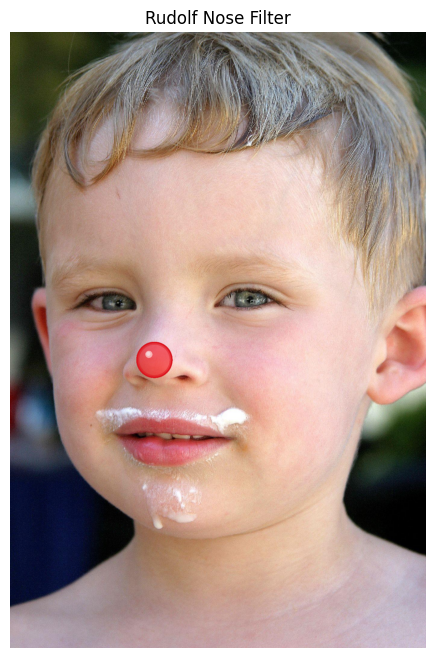

In [74]:
# 루돌프 코 이미지 불러오기
rudolf_nose = cv2.imread('../data/assets/rudolf_nose.png', cv2.IMREAD_UNCHANGED)

if rudolf_nose is None:
    print("❌ 루돌프 코 이미지를 찾을 수 없습니다!")
else:
    # 테스트 이미지
    test_img = cv2.imread('../data/test/images/26638112_1.jpg')
    
    result_img = draw_rudolf_nose(test_img, model, rudolf_nose)
    
    # 결과 시각화
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.title('Rudolf Nose Filter')
    plt.axis('off')
    plt.show()

---
### 6️⃣ Level 2: 선글라스 필터 만들기 🕶️ 

##### 목표
- 투명 배경 PNG 이미지를 얼굴에 합성
- 얼굴 각도에 맞춰 이미지 회전
- 얼굴 크기에 맞춰 이미지 크기 조절

##### 핵심
1. **크기 조절**: 두 눈 사이 거리에 비례
2. **회전 각도**: `θ = arctan2(Δy, Δx)`
3. **Alpha Blending**: 투명 배경 처리

In [79]:
def draw_sunglasses(frame, model, glasses_img):
    
    results = model(frame, verbose=False)
    if results[0].keypoints is None or len(results[0].keypoints.xy) == 0:
        return frame
    keypoints = results[0].keypoints.xy[0].cpu().numpy()
    
    
    # 🎯 [미션 5] 왼쪽/오른쪽 눈의 중심점 구하기
    left_eye_center = keypoints[36:42].mean(axis=0)     # [왼쪽 눈 시작 점번호: 왼쪽 눈 종료 점번호]
    right_eye_center = keypoints[42:48].mean(axis=0)    # [오른쪽 눈 시작 점번호: 오른쪽 눈 종료 점번호]
    
    # 두 눈 사이 거리 계산 (크기 조절의 기준)
    eye_distance = np.linalg.norm(right_eye_center - left_eye_center)
    
    # 선글라스 크기 설정 (눈 간격의 2배로 설정)
    glasses_width = int(eye_distance * 2.0)
    
    # 비율 유지하며 리사이즈 (Resize)
    aspect_ratio = glasses_img.shape[0] / glasses_img.shape[1]
    glasses_height = int(glasses_width * aspect_ratio)
    glasses_resized = cv2.resize(glasses_img, (glasses_width, glasses_height))
    
    # 🎯 [미션 3] 얼굴 각도 계산 (기울어진 정도)
    # 아크탄젠트(atan2)를 사용하여 두 눈 사이의 기울기를 구합니다.
    angle = np.degrees(np.arctan2(
        right_eye_center[1] - left_eye_center[1],
        right_eye_center[0] - left_eye_center[0]
    ))
    
    # 이미지 회전 적용 (Rotation)
    (h, w) = glasses_resized.shape[:2]
    rotation_matrix = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    glasses_rotated = cv2.warpAffine(
        glasses_resized, 
        rotation_matrix, 
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0, 0) # 빈 공간은 투명하게 처리
    )
    
    # 🎯 [미션 4] 중심점 기준 붙일 위치(좌상단) 계산
    # 두 눈의 정중앙 좌표 구하기
    center_point = ((left_eye_center + right_eye_center) / 2).astype(int)
    
    # 이미지를 붙일 시작점(x, y) 계산
    x = center_point[0] - glasses_width // 2
    y = center_point[1] - glasses_height // 2 
    
    # 이미지 합성 (투명 배경 처리 포함)
    frame = overlay_transparent(frame, glasses_rotated, x, y)
    
    return frame

✅ 선글라스 이미지 로드 완료: (400, 1000, 4)


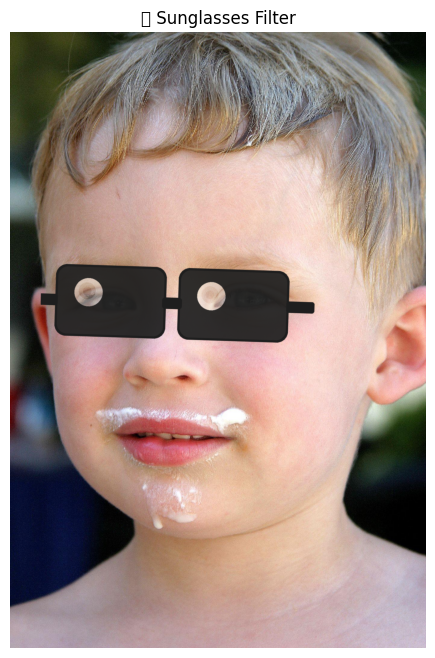

In [ ]:
glasses = cv2.imread('../data/assets/sunglasses_classic.png', cv2.IMREAD_UNCHANGED)

if glasses is None:
    print("❌ 선글라스 이미지를 찾을 수 없습니다!")
else:
    print(f"✅ 선글라스 이미지 로드 완료: {glasses.shape}")
    
    test_img = cv2.imread('../data/test/images/26638112_1.jpg')
    
    if test_img is not None:
        result_img = draw_sunglasses(test_img, model, glasses)
        
        # 결과 출력
        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
        plt.title('Sunglasses Filter')
        plt.axis('off')
        plt.show()